In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

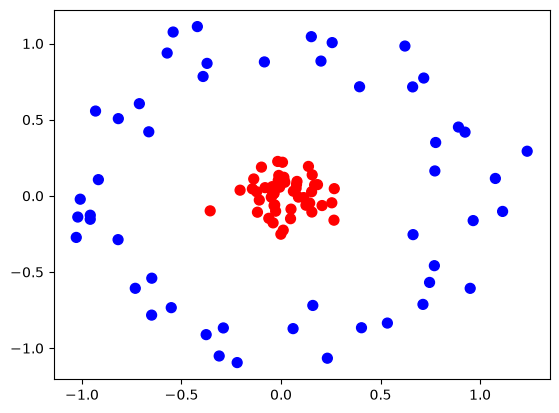

In [71]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')
plt.show()

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

# LINEAR SVM

In [73]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

### BAD

In [74]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.55

In [75]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\ANAND SHARMA\AppData\Local\Temp\ipykernel_20732\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


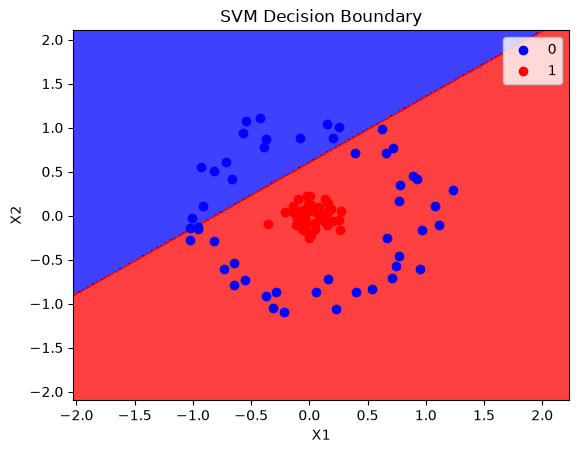

In [76]:
plot_decision_boundary(X, y, classifier)

# WITH RBF KERNAL

In [77]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

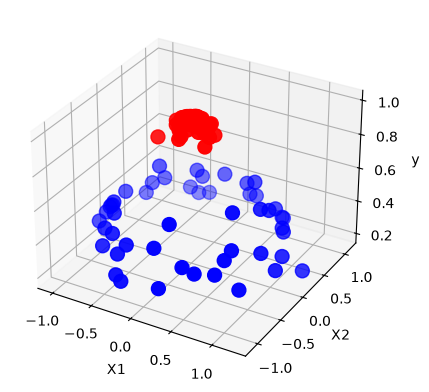

In [78]:
plot_3d_plot(X,y)

In [79]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

### DAMN GOOD 

In [80]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\ANAND SHARMA\AppData\Local\Temp\ipykernel_20732\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


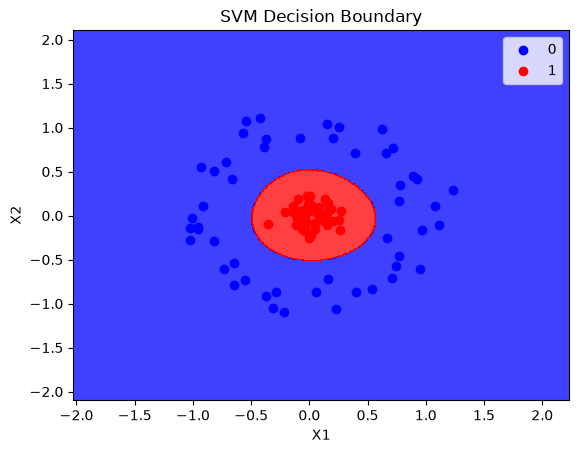

In [81]:
plot_decision_boundary(X, y, rbf_classifier)

# POLYNOMIAL KERNAL

In [82]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

### ALSO GOOD

In [83]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\ANAND SHARMA\AppData\Local\Temp\ipykernel_20732\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


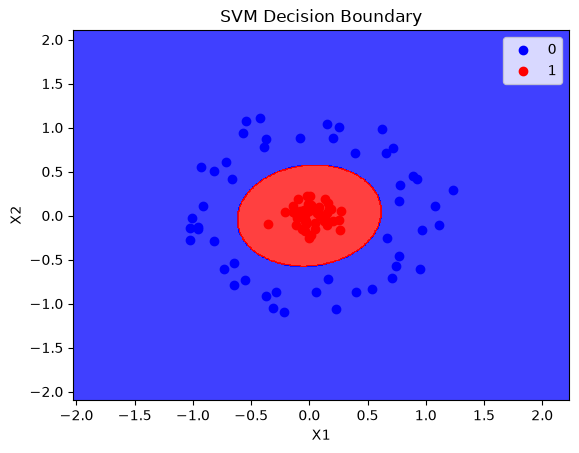

In [84]:
plot_decision_boundary(X, y, poly_classifier)

In [85]:
X

array([[-3.16271986e-02, -5.96246656e-02],
       [-1.39926865e-02,  1.01427784e-01],
       [ 1.83335919e-01,  7.36169159e-02],
       [-3.97544038e-02, -1.77493366e-01],
       [ 1.11317355e+00, -1.02371974e-01],
       [ 7.76989003e-01,  3.50192418e-01],
       [ 2.66046370e-01, -1.59810012e-01],
       [-2.77135599e-02,  4.84460529e-02],
       [-9.31647065e-01,  5.56635837e-01],
       [ 8.91346764e-01,  4.51488517e-01],
       [-3.71483328e-01,  8.69581008e-01],
       [-1.43758349e-01,  4.60422017e-02],
       [ 4.04298213e-01, -8.65941698e-01],
       [-1.64717845e-02,  2.25746705e-01],
       [-9.58157858e-01, -1.27172002e-01],
       [-5.51340260e-01, -7.34094004e-01],
       [-8.02069747e-02,  5.36572472e-02],
       [-6.13725541e-02, -1.47490816e-01],
       [ 2.32917394e-01, -1.06602483e+00],
       [ 9.50399097e-01, -6.07262499e-01],
       [ 7.13107782e-01, -7.12659166e-01],
       [-4.88432227e-02, -8.73262811e-03],
       [ 1.44087418e-01, -4.76550953e-02],
       [ 6.

In [86]:
np.exp(-(X**2)).sum(1)

array([1.99545143, 1.98956936, 1.96154176, 1.96740802, 1.27920345,
       1.43136499, 1.90645034, 1.99688799, 1.15336624, 1.26739883,
       1.34055931, 1.97742799, 1.32163802, 1.9500439 , 1.38324769,
       1.32127164, 1.99071253, 1.97472186, 1.26816437, 1.09683305,
       1.20315146, 1.99754093, 1.97718441, 1.58122615, 1.31262476,
       1.26493348, 1.4323733 , 1.13633659, 1.99670384, 1.99166336,
       1.98505551, 1.27538535, 1.99227722, 1.24934312, 1.36110675,
       1.98988603, 1.36773707, 1.9883214 , 1.36280731, 1.13447425,
       1.12907872, 1.95692723, 1.87142405, 1.45469922, 1.24541336,
       1.93851073, 1.52391163, 1.98915852, 1.97546091, 1.99470702,
       1.28624755, 1.05896029, 1.99522116, 1.99853814, 1.29682827,
       1.45457793, 1.95721844, 1.97462325, 1.29618586, 1.48133448,
       1.33349328, 1.29953947, 1.23911108, 1.94456102, 1.14790227,
       1.9650337 , 1.96690034, 1.39083583, 1.95252494, 1.99183488,
       1.95550092, 1.92867574, 1.99595862, 1.4197045 , 1.30066

In [87]:
X_new=np.exp(-(X**2))

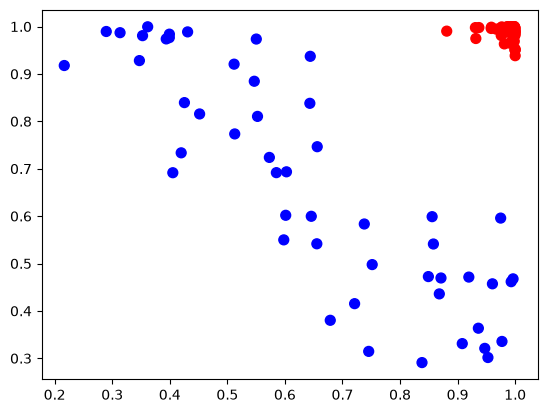

In [88]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')